In [1]:
import pandas as pd
df = pd.read_csv('feature_eng_df_final.csv')

In [2]:
# dropping credit score category since it already encoded as new column credit_score_numeric
df.drop('credit_score_category',axis=1,inplace=True)

In [3]:
#let's encode the binned age group column derived from age column in to ordinal encoder
df['age_group'].unique()
age_group_order = ['25-34','35-44', '45-54', '55-64']
from sklearn.preprocessing import OrdinalEncoder
age_group_encoder = OrdinalEncoder(categories=[age_group_order])
df['age_group'] = age_group_encoder.fit_transform(df[['age_group']])
print("after encoding df['age_group']",df['age_group'].unique())
df.drop('age',axis=1,inplace=True)

after encoding df['age_group'] [1. 3. 2. 0.]


In [4]:
#let encode binned employment experience type from year_of_employment column 
df['employment_tenure_category'].unique()
employment_order = ['Entry-level', 'Mid-level', 'Experienced']
emp_category_encoder = OrdinalEncoder(categories=[employment_order])
df['employment_tenure_category'] = emp_category_encoder.fit_transform(df[['employment_tenure_category']])
print("after encoding emp tenure category ",df['employment_tenure_category'].unique())
df.drop('years_of_employment',axis=1,inplace=True)

after encoding emp tenure category  [0. 1. 2.]


In [5]:
#let drop emi eligibility - another targer variable
df.drop('emi_eligibility',axis=1,inplace=True)

In [6]:
from sklearn.model_selection import train_test_split
X=df.drop(['max_monthly_emi'],axis=1)
y=df['max_monthly_emi']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(322243, 40)
(80561, 40)
(322243,)
(80561,)


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error

In [8]:
standardscaler = StandardScaler()
columns_to_scale = ['monthly_salary','family_size','dependents','current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund','requested_amount','requested_tenure','debt_to_income_ratio', 'total_expenses', 'expense_to_income_ratio',
       'affordability_ratio', 'credit_score_numeric', 'combined_credit_risk',
       'income_per_family_member', 'savings_to_income_ratio',
       'credit_stability_score', 'loan_affordability_index']
# Filter columns_to_scale to ensure they exist in the DataFrame
existing_columns_to_scale = [col for col in columns_to_scale if col in df.columns]

if existing_columns_to_scale:
    # Apply StandardScaler to the identified numerical columns
    X_train[existing_columns_to_scale] = standardscaler.fit_transform(X_train[existing_columns_to_scale])
    X_test[existing_columns_to_scale]  = standardscaler.fit_transform(X_test[existing_columns_to_scale])
    print("Scaled the following columns:", existing_columns_to_scale)
    #display(x[existing_columns_to_scale].head())
else:
    print("No existing columns found to scale from the provided list.")

Scaled the following columns: ['monthly_salary', 'family_size', 'dependents', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'debt_to_income_ratio', 'total_expenses', 'expense_to_income_ratio', 'affordability_ratio', 'credit_score_numeric', 'combined_credit_risk', 'income_per_family_member', 'savings_to_income_ratio', 'credit_stability_score', 'loan_affordability_index']


In [9]:
linear_model = LinearRegression()

In [10]:
linear_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_predict = linear_model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test,y_predict)
print("mean absolute error--",mae)
mse = mean_squared_error(y_test,y_predict)
print("mean square error--",mse)
r2_scr = r2_score(y_test,y_predict)
print("r2 score",r2_scr)
mape = mean_absolute_percentage_error(y_test, y_predict)
print("MAPE:", mape * 100)

mean absolute error-- 0.5088737805366155
mean square error-- 0.4477951591955399
r2 score 0.7586547918097868
MAPE: 6.8297180772689465


In [13]:
x_predict = linear_model.predict(X_train)
x_mae = mean_absolute_error(y_train,x_predict)
print("mean absolute error--",x_mae)
x_mse = mean_squared_error(y_train,x_predict)
print("mean square error--",x_mse)
r2_scr = r2_score(y_train,x_predict)
print("r2 score",r2_scr)
mape = mean_absolute_percentage_error(y_test, y_predict)
print("MAPE:", mape * 100)

mean absolute error-- 0.5079442933050893
mean square error-- 0.44491719960706677
r2 score 0.7608395519541162
MAPE: 6.8297180772689465


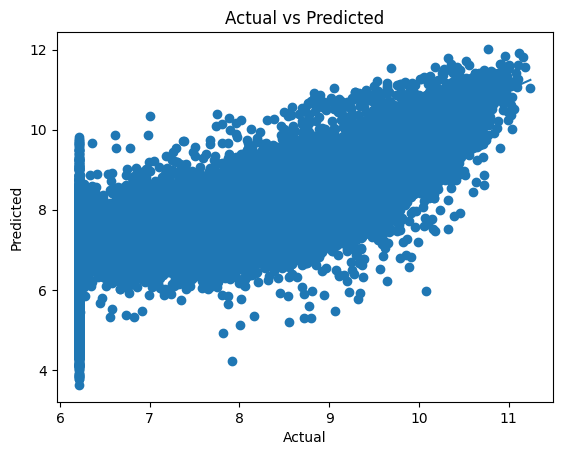

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_predict)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

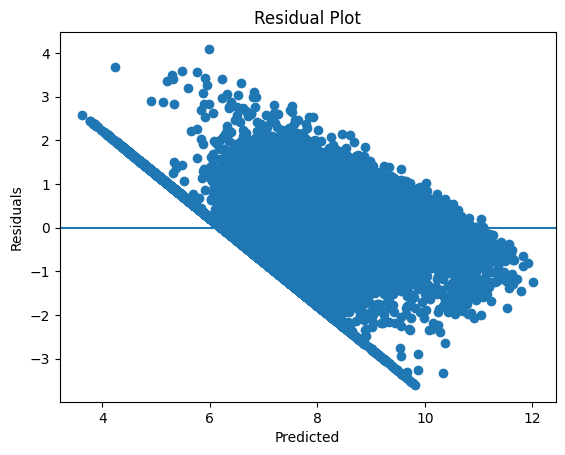

In [15]:
residuals = y_test - y_predict

plt.figure()
plt.scatter(y_predict, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

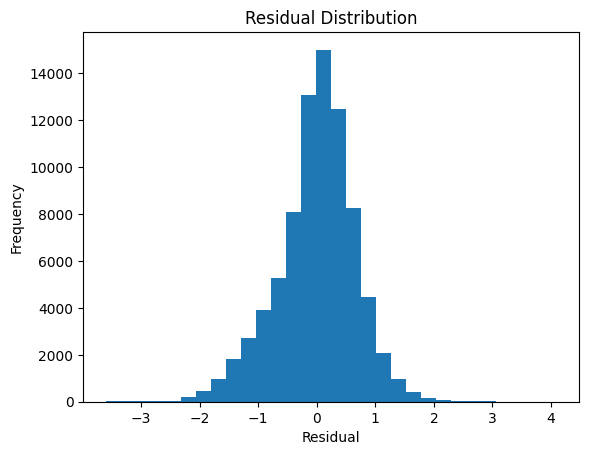

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

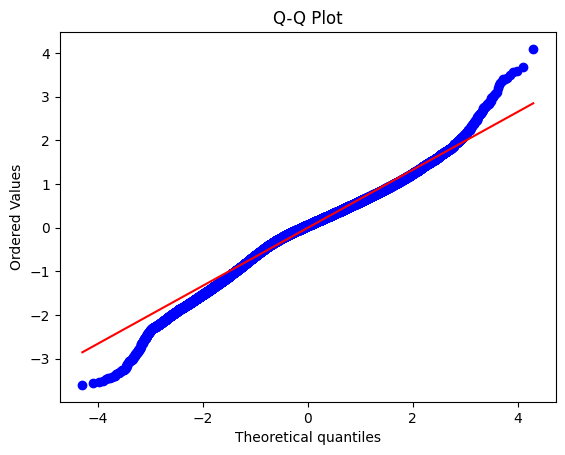

In [17]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

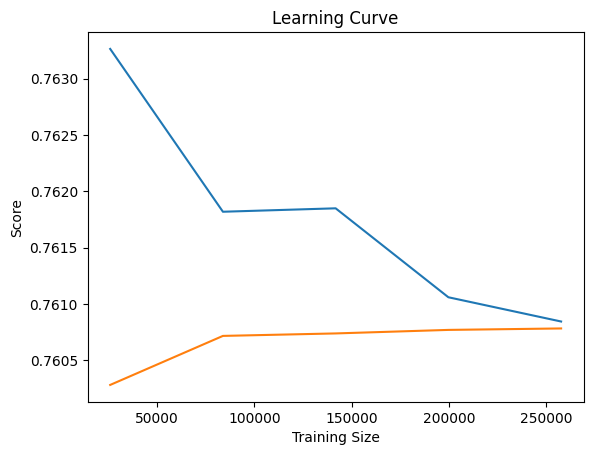

In [18]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    linear_model, X_train, y_train, cv=5)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean)
plt.plot(train_sizes, test_mean)
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.show()

In [19]:
coeff_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
})

print(coeff_df.sort_values(by="Coefficient", ascending=False))

                          Feature  Coefficient
12                 existing_loans     1.313967
31            affordability_ratio     0.713563
33           combined_credit_risk     0.711491
28           debt_to_income_ratio     0.711158
1                  monthly_salary     0.439068
10            groceries_utilities     0.370532
39       loan_affordability_index     0.219308
15                   bank_balance     0.148409
9                 travel_expenses     0.133885
16                 emergency_fund     0.100904
38         credit_stability_score     0.073068
25     employment_type_Government     0.059346
0                       education     0.048657
14                   credit_score     0.030131
36       income_per_family_member     0.008624
6                      dependents     0.001653
5                     family_size     0.001653
2                    company_type     0.001102
23         marital_status_Married     0.000868
17                   emi_scenario     0.000630
21           

In [21]:
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import learning_curve

mlflow.set_experiment("Max Monthly EMI Prediction Linear Regression experiment v2")
mlflow.set_tracking_uri("http://127.0.0.1:5000")
# Start an MLflow run
with mlflow.start_run():
    
    # 1. Log Metrics
    mae = mean_absolute_error(y_test, y_predict)
    mse = mean_squared_error(y_test, y_predict)
    r2_scr = r2_score(y_test, y_predict)
    mape = mean_absolute_percentage_error(y_test, y_predict)

    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2_score", r2_scr)
    mlflow.log_metric("mape", mape)

    # 2. Log Plots (Actual vs Predicted)
    fig_res = plt.figure()
    plt.scatter(y_test, y_predict)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted")
    mlflow.log_figure(fig_res, "plots/actual_vs_predicted.png")
    plt.close(fig_res)

    # 3. Log Residual Plot
    residuals = y_test - y_predict
    fig_resid = plt.figure()
    plt.scatter(y_predict, residuals)
    plt.axhline(y=0, color='r', linestyle='-')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    mlflow.log_figure(fig_resid, "plots/residual_plot.png")
    plt.close(fig_resid)

    # 4. Log Residual Distribution
    fig_hist = plt.figure()
    plt.hist(residuals, bins=30)
    plt.title("Residual Distribution")
    mlflow.log_figure(fig_hist, "plots/residual_dist.png")
    plt.close(fig_hist)

    # 5. Log Q-Q Plot
    fig_qq = plt.figure()
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title("Q-Q Plot")
    mlflow.log_figure(fig_qq, "plots/qq_plot.png")
    plt.close(fig_qq)

    # 6. Log Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        linear_model, X_train, y_train, cv=5)
    
    fig_lc = plt.figure()
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train Score")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-Val Score")
    plt.xlabel("Training Size")
    plt.ylabel("Score")
    plt.title("Learning Curve")
    plt.legend()
    mlflow.log_figure(fig_lc, "plots/learning_curve.png")
    plt.close(fig_lc)

    # 7. Log Coefficients as a CSV Artifact
    coeff_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": linear_model.coef_
    }).sort_values(by="Coefficient", ascending=False)
    
    coeff_df.to_csv("coefficients.csv", index=False)
    mlflow.log_artifact("coefficients.csv")

    # 8. Log the Model itself
    mlflow.sklearn.log_model(linear_model, "linear Regression model")

    print("Experiment logged successfully to MLflow!")

2026/02/26 20:51:45 INFO mlflow.tracking.fluent: Experiment with name 'Max Monthly EMI Prediction Linear Regression experiment v2' does not exist. Creating a new experiment.
2026/02/26 20:53:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
C:\Users\RAM\miniconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Experiment logged successfully to MLflow!
🏃 View run useful-moose-701 at: http://127.0.0.1:5000/#/experiments/9/runs/abcf3e4bace845d591f9ecc10aae9e16
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/9
